In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

earn = pd.read_csv("college-earnings.csv")

SCHOOL = "INSTNM"
P10 = "PCT10_EARN_WNE_P10"
P25 = "PCT25_EARN_WNE_P10"
P50 = "PCT50_EARN_WNE_P10" if "PCT50_EARN_WNE_P10" in earn.columns else "MD_EARN_WNE_P10"
P75 = "PCT75_EARN_WNE_P10"
P90 = "PCT90_EARN_WNE_P10"

cols = [SCHOOL, P10, P25, P50, P75, P90]
df = earn[cols].copy()

for c in [P10, P25, P50, P75, P90]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

name_map = {
    "University of Pennsylvania": "UPenn",
    "Princeton University": "Princeton",
    "Cornell University": "Cornell",
    "Columbia University in the City of New York": "Columbia",
    "Harvard University": "Harvard",
    "Yale University": "Yale",
    "Dartmouth College": "Dartmouth",
    "Brown University": "Brown",
}

df = df[df[SCHOOL].isin(name_map.keys())].dropna()
df["School"] = df[SCHOOL].map(name_map)
df = df.sort_values(P50, ascending=False)

palette = {
    "Harvard":   "#E1888B",
    "UPenn":     "#CD868A",
    "Princeton": "#FFA18A",
    "Columbia":  "#A5CEEE",
    "Cornell":   "#DD8786",
    "Dartmouth": "#899F96",
    "Yale":      "#8B90AA",
    "Brown":     "#9F958F",
}


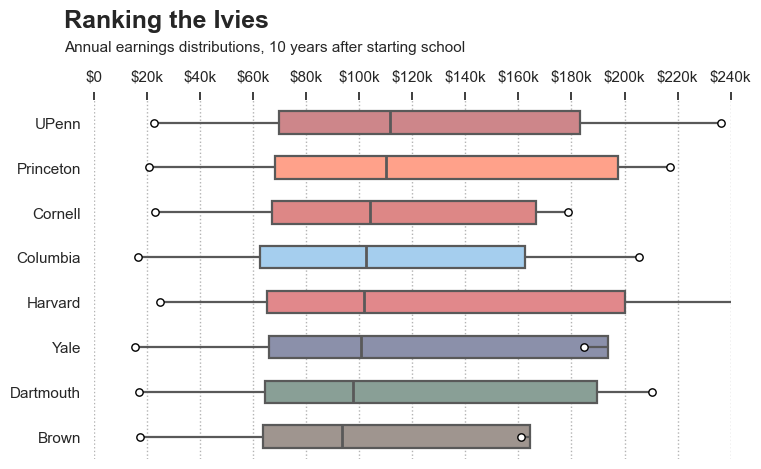

In [10]:
sns.set_theme(style="white")

stats = []
for _, r in df.iterrows():
    stats.append({
        "label": r["School"],
        "whislo": r[P10],
        "q1": r[P25],
        "med": r[P50],
        "q3": r[P75],
        "whishi": r[P90],
        "fliers": []
    })

fig, ax = plt.subplots(figsize=(8.6, 5.2))

ticks = list(range(0, 240001, 20000))
for t in ticks:
    ax.axvline(t, color="0.7", linestyle=":", linewidth=1, zorder=0)

bp = ax.bxp(
    stats,
    vert=False,
    patch_artist=True,
    showcaps=False,
    showfliers=False,
    boxprops={"edgecolor": "0.35", "linewidth": 1.6},
    whiskerprops={"color": "0.35", "linewidth": 1.6},
    medianprops={"color": "0.35", "linewidth": 2.0},
)

for box, school in zip(bp["boxes"], df["School"].tolist()):
    box.set_facecolor(palette[school])

for i in range(len(df)):
    ax.scatter([df.iloc[i][P10], df.iloc[i][P90]], [i + 1, i + 1],
               s=28, facecolors="white", edgecolors="black", zorder=3)

ax.set_xlim(0, 240000)
ax.set_xticks(ticks)
ax.set_xticklabels(["$0"] + [f"${t//1000}k" for t in ticks[1:]])
ax.xaxis.tick_top()
ax.tick_params(axis="x", pad=6, top=True, labeltop=True, bottom=False, labelbottom=False)

ax.set_xlabel("")
ax.set_ylabel("")

ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.invert_yaxis()

fig.text(0.125, 0.975, "Ranking the Ivies", ha="left", va="top", fontsize=18, fontweight="bold")
fig.text(0.125, 0.915, "Annual earnings distributions, 10 years after starting school",
         ha="left", va="top", fontsize=11)

plt.subplots_adjust(top=0.80, left=0.16)
plt.show()


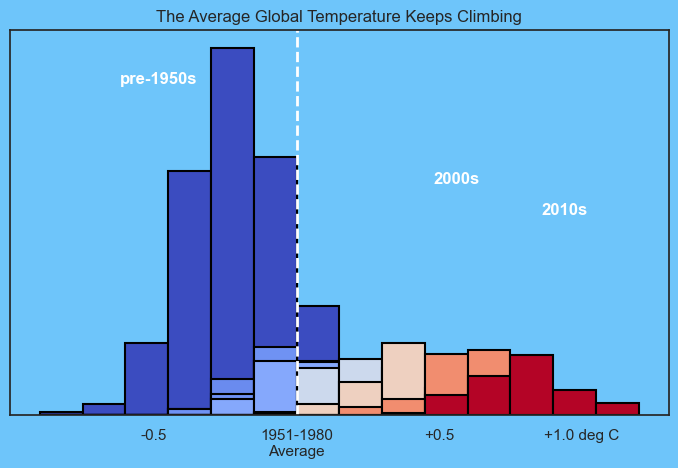

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  

temps = pd.read_csv("temps.csv")

YEAR_COL = "Year" if "Year" in temps.columns else temps.columns[0]
month_cols = [c for c in temps.columns if c != YEAR_COL]

long = temps.melt(id_vars=[YEAR_COL], value_vars=month_cols, var_name="Month", value_name="Dev")
long["Dev"] = pd.to_numeric(long["Dev"], errors="coerce")
long = long.dropna()

long = long[long[YEAR_COL] <= 2019].copy()
long["Decade"] = long[YEAR_COL].apply(lambda y: "pre-1950s" if y < 1950 else f"{(y//10)*10}s")

order = ["pre-1950s", "1950s", "1960s", "1970s", "1980s", "1990s", "2000s", "2010s"]
dec_means = long.groupby("Decade")["Dev"].mean().reindex(order)

pal = sns.color_palette("coolwarm", 256)
mn, mx = float(dec_means.min()), float(dec_means.max())

def decade_color(mean_val):
    t = 0.0 if mx == mn else (mean_val - mn) / (mx - mn)
    idx = int(round(t * 255))
    return pal[idx]

bins = []
start, end, step = -0.9, 1.3, 0.15
v = start
while v <= end + 1e-9:
    bins.append(v)
    v += step

fig, ax = plt.subplots(figsize=(8.5, 5))
fig.patch.set_facecolor("#6EC5FA")
ax.set_facecolor("#6EC5FA")

for d in order:
    vals = long.loc[long["Decade"] == d, "Dev"]
    if len(vals) == 0:
        continue
    ax.hist(vals, bins=bins, color=decade_color(float(dec_means.loc[d])),
            edgecolor="black", linewidth=1.5)

ax.axvline(0, color="white", linestyle="--", linewidth=2)

ax.set_title("The Average Global Temperature Keeps Climbing")
ax.set_yticks([])

ax.set_xticks([-0.5, 0.0, 0.5, 1.0])
ax.set_xticklabels(["-0.5", "1951-1980\nAverage", "+0.5", "+1.0 deg C"])

ymax = ax.get_ylim()[1]
ax.text(-0.62, ymax * 0.86, "pre-1950s", color="white", fontweight="bold")
ax.text(0.48, ymax * 0.60, "2000s", color="white", fontweight="bold")
ax.text(0.86, ymax * 0.52, "2010s", color="white", fontweight="bold")

plt.show()

